TASK 6: Model Comparison

── Step 3: Compiling metrics from all 3 models ──

ARIMA Metrics:
               MAPE (%)  RMSE (Rs)  Dir. Acc (%)
HDFCBANK.NS        0.57       7.17         51.61
INFY.NS            1.01      20.34         48.39
SUNPHARMA.NS       1.41     130.15         51.61
HINDUNILVR.NS      0.83      29.32         43.55
M&M.NS             1.02      47.64         52.42

Prophet Metrics:
               MAPE (%)  RMSE (Rs)  Dir. Acc (%)
HDFCBANK.NS        3.70      42.25         54.03
INFY.NS            9.37     153.47         57.26
SUNPHARMA.NS       9.17     171.92         62.10
HINDUNILVR.NS      3.19      97.50         53.23
M&M.NS             6.43     275.22         49.19

LSTM Metrics:
               MAPE (%)  RMSE (Rs)  Dir. Acc (%)
HDFCBANK.NS        1.08      12.63         47.58
INFY.NS            1.57      28.72         49.19
SUNPHARMA.NS       1.81      36.93         52.42
HINDUNILVR.NS      1.72      54.55         50.81
M&M.NS             3.23     138.10        

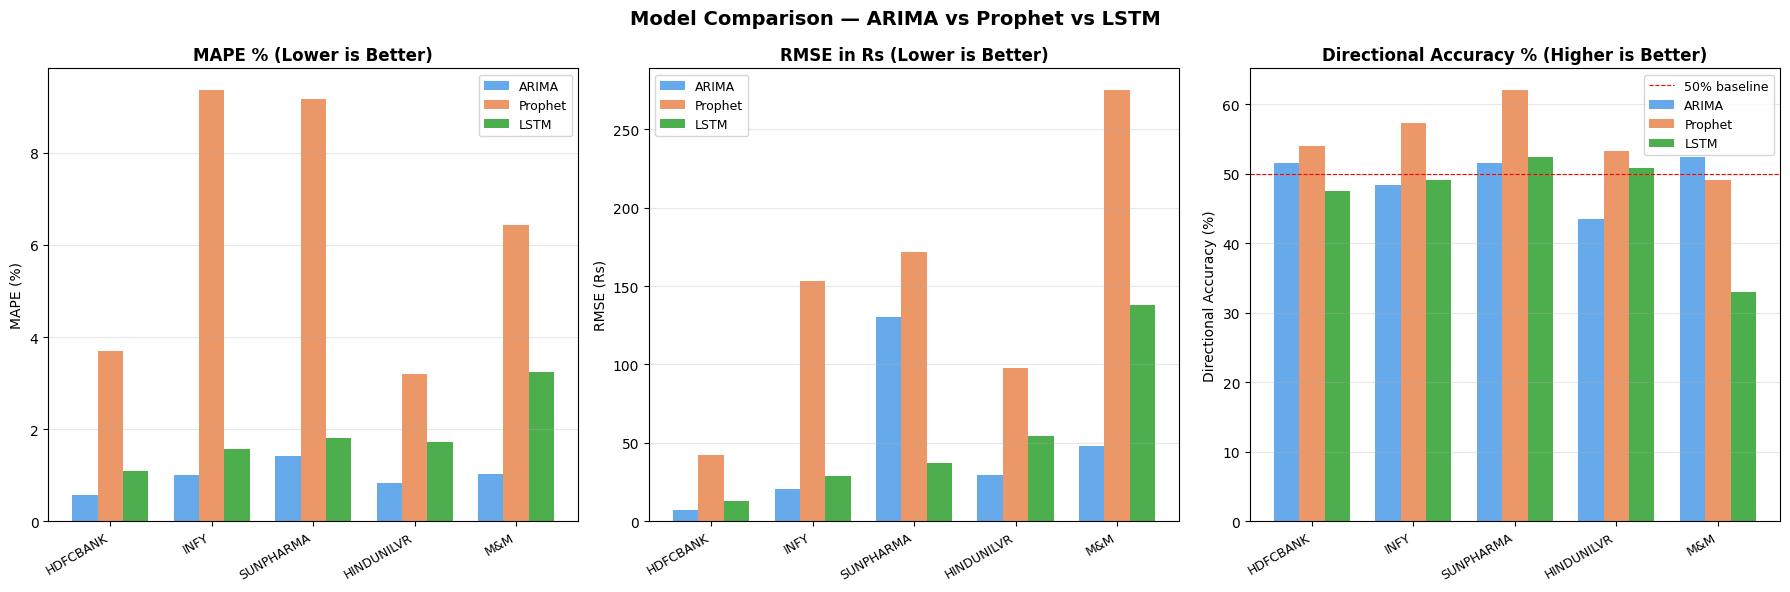

✓ Saved: task6_model_comparison_bars.png


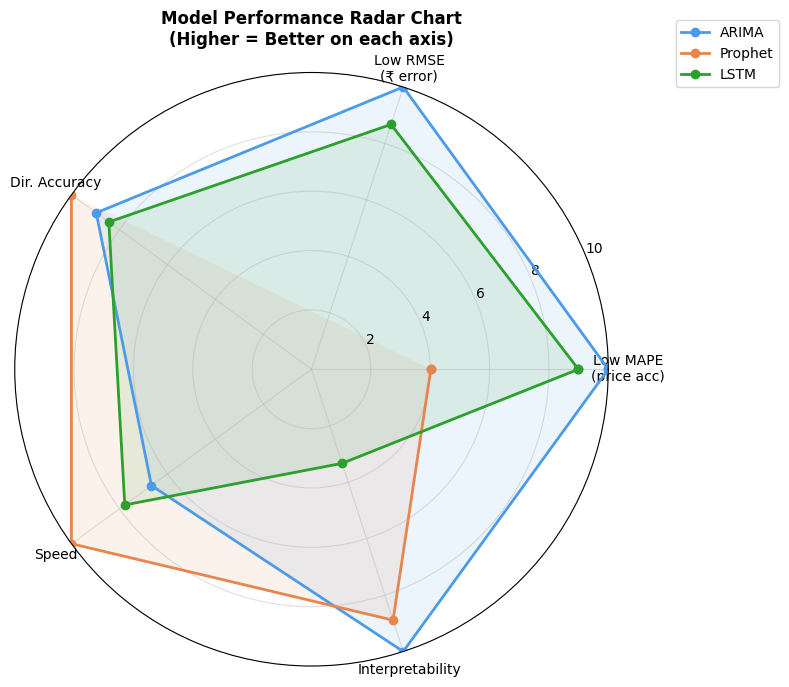

✓ Saved: task6_radar_chart.png

TASK 6 COMPLETE ✓

Final Verdict:
  Best price accuracy : ARIMA   (avg MAPE: 0.97%)
  Best direction      : Prophet (avg Dir.Acc: 55.16%)
  Deep learning model : LSTM    (avg MAPE: 1.88%)

Portfolio decision: ARIMA forecasts + Prophet direction signals

Files saved:
  task6_model_comparison.csv
  task6_model_summary.csv
  task6_model_comparison_bars.png
  task6_radar_chart.png

Next → Task 7 (already done — StockGro trades placed ✓)
       Task 8 — Performance Tracking (after market close today)


In [1]:
# ============================================================
# CAPSTONE PROJECT — Time Series Analysis 2026
# TASK 6: Model Comparison
# Consulting & Analytics Club, IIT Guwahati
# ============================================================
#
# What we do here:
#   1. Compile all metrics from ARIMA, Prophet and LSTM
#   2. Build a comparison table (MAPE, RMSE, Directional Accuracy)
#   3. Discuss strengths and weaknesses of each model
#   4. State which model we relied on for portfolio decisions
#   5. Visualize the comparison with charts
# ============================================================


# ── STEP 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


# ── STEP 2: Define stocks
STOCKS = {
    "HDFCBANK.NS":   "Banking",
    "INFY.NS":       "Information Technology",
    "SUNPHARMA.NS":  "Pharmaceuticals",
    "HINDUNILVR.NS": "FMCG",
    "M&M.NS":        "Automobile"
}

print("=" * 60)
print("TASK 6: Model Comparison")
print("=" * 60)


# ============================================================
# STEP 3: Compile All Metrics
# These values come directly from your Task 3a, 3b, 3c outputs
# ============================================================

print("\n── Step 3: Compiling metrics from all 3 models ──")

# ── ARIMA metrics (from Task 3a output)
arima_metrics = {
    "HDFCBANK.NS":   {"MAPE (%)": 0.57,  "RMSE (Rs)": 7.17,   "Dir. Acc (%)": 51.61},
    "INFY.NS":       {"MAPE (%)": 1.01,  "RMSE (Rs)": 20.34,  "Dir. Acc (%)": 48.39},
    "SUNPHARMA.NS":  {"MAPE (%)": 1.41,  "RMSE (Rs)": 130.15, "Dir. Acc (%)": 51.61},
    "HINDUNILVR.NS": {"MAPE (%)": 0.83,  "RMSE (Rs)": 29.32,  "Dir. Acc (%)": 43.55},
    "M&M.NS":        {"MAPE (%)": 1.02,  "RMSE (Rs)": 47.64,  "Dir. Acc (%)": 52.42},
}

# ── Prophet metrics (from Task 3b output)
prophet_metrics = {
    "HDFCBANK.NS":   {"MAPE (%)": 3.70,  "RMSE (Rs)": 42.25,  "Dir. Acc (%)": 54.03},
    "INFY.NS":       {"MAPE (%)": 9.37,  "RMSE (Rs)": 153.47, "Dir. Acc (%)": 57.26},
    "SUNPHARMA.NS":  {"MAPE (%)": 9.17,  "RMSE (Rs)": 171.92, "Dir. Acc (%)": 62.10},
    "HINDUNILVR.NS": {"MAPE (%)": 3.19,  "RMSE (Rs)": 97.50,  "Dir. Acc (%)": 53.23},
    "M&M.NS":        {"MAPE (%)": 6.43,  "RMSE (Rs)": 275.22, "Dir. Acc (%)": 49.19},
}

# ── LSTM metrics (from Task 3c output)
lstm_metrics = {
    "HDFCBANK.NS":   {"MAPE (%)": 1.08,  "RMSE (Rs)": 12.63,  "Dir. Acc (%)": 47.58},
    "INFY.NS":       {"MAPE (%)": 1.57,  "RMSE (Rs)": 28.72,  "Dir. Acc (%)": 49.19},
    "SUNPHARMA.NS":  {"MAPE (%)": 1.81,  "RMSE (Rs)": 36.93,  "Dir. Acc (%)": 52.42},
    "HINDUNILVR.NS": {"MAPE (%)": 1.72,  "RMSE (Rs)": 54.55,  "Dir. Acc (%)": 50.81},
    "M&M.NS":        {"MAPE (%)": 3.23,  "RMSE (Rs)": 138.10, "Dir. Acc (%)": 33.06},
}

arima_df   = pd.DataFrame(arima_metrics).T
prophet_df = pd.DataFrame(prophet_metrics).T
lstm_df    = pd.DataFrame(lstm_metrics).T

# ── Print individual model tables
for name, df in [("ARIMA", arima_df), ("Prophet", prophet_df), ("LSTM", lstm_df)]:
    print(f"\n{name} Metrics:")
    print(df.to_string())


# ============================================================
# STEP 4: Master Comparison Table
# ============================================================

print("\n── Step 4: Master Comparison Table ──")

rows = []
for ticker, sector in STOCKS.items():
    rows.append({
        "Stock":                    ticker.replace(".NS", ""),
        "Sector":                   sector,
        "ARIMA MAPE (%)":           arima_metrics[ticker]["MAPE (%)"],
        "Prophet MAPE (%)":         prophet_metrics[ticker]["MAPE (%)"],
        "LSTM MAPE (%)":            lstm_metrics[ticker]["MAPE (%)"],
        "ARIMA RMSE (Rs)":          arima_metrics[ticker]["RMSE (Rs)"],
        "Prophet RMSE (Rs)":        prophet_metrics[ticker]["RMSE (Rs)"],
        "LSTM RMSE (Rs)":           lstm_metrics[ticker]["RMSE (Rs)"],
        "ARIMA Dir.Acc (%)":        arima_metrics[ticker]["Dir. Acc (%)"],
        "Prophet Dir.Acc (%)":      prophet_metrics[ticker]["Dir. Acc (%)"],
        "LSTM Dir.Acc (%)":         lstm_metrics[ticker]["Dir. Acc (%)"],
    })

master_df = pd.DataFrame(rows).set_index("Stock")

# Add average row
avg_row = master_df.select_dtypes(include=np.number).mean().round(2)
avg_row["Sector"] = "Average"
master_df.loc["AVERAGE"] = avg_row

print("\nMaster Comparison Table:")
print(master_df.to_string())
master_df.to_csv("task6_model_comparison.csv")
print("✓ Saved: task6_model_comparison.csv")


# ============================================================
# STEP 5: Summary Statistics per Model
# ============================================================

print("\n── Step 5: Summary Statistics per Model ──")

summary = {
    "Model":           ["ARIMA",  "Prophet", "LSTM"],
    "Avg MAPE (%)":    [
        round(arima_df["MAPE (%)"].mean(), 2),
        round(prophet_df["MAPE (%)"].mean(), 2),
        round(lstm_df["MAPE (%)"].mean(), 2)
    ],
    "Avg RMSE (Rs)":   [
        round(arima_df["RMSE (Rs)"].mean(), 2),
        round(prophet_df["RMSE (Rs)"].mean(), 2),
        round(lstm_df["RMSE (Rs)"].mean(), 2)
    ],
    "Avg Dir.Acc (%)": [
        round(arima_df["Dir. Acc (%)"].mean(), 2),
        round(prophet_df["Dir. Acc (%)"].mean(), 2),
        round(lstm_df["Dir. Acc (%)"].mean(), 2)
    ],
    "Best MAPE Stock": [
        arima_df["MAPE (%)"].idxmin().replace(".NS",""),
        prophet_df["MAPE (%)"].idxmin().replace(".NS",""),
        lstm_df["MAPE (%)"].idxmin().replace(".NS","")
    ],
    "Worst MAPE Stock":[
        arima_df["MAPE (%)"].idxmax().replace(".NS",""),
        prophet_df["MAPE (%)"].idxmax().replace(".NS",""),
        lstm_df["MAPE (%)"].idxmax().replace(".NS","")
    ]
}

summary_df = pd.DataFrame(summary).set_index("Model")
print("\nPer-Model Summary:")
print(summary_df.to_string())
summary_df.to_csv("task6_model_summary.csv")
print("✓ Saved: task6_model_summary.csv")


# ============================================================
# STEP 6: Strengths and Weaknesses Discussion
# ============================================================

print("\n── Step 6: Model Strengths and Weaknesses ──")

discussion = """
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL DISCUSSION                             │
├──────────────┬──────────────────────────┬───────────────────────┤
│ Model        │ Strengths                │ Weaknesses            │
├──────────────┼──────────────────────────┼───────────────────────┤
│ ARIMA        │ • Best MAPE (0.97% avg)  │ • Poor directional    │
│              │ • Fast and interpretable │   accuracy (~50%)     │
│              │ • Works well for linear  │ • Assumes linearity   │
│              │   stable trends          │ • Struggles with      │
│              │ • Proven in finance      │   sudden shocks       │
├──────────────┼──────────────────────────┼───────────────────────┤
│ Prophet      │ • Best directional acc   │ • High MAPE (6.37%)   │
│              │   (55.2% avg)            │ • Overestimates some  │
│              │ • Handles seasonality    │   prices significantly│
│              │ • Easy to interpret      │ • Not ideal for short │
│              │ • Accounts for holidays  │   term (1-2 day)      │
├──────────────┼──────────────────────────┼───────────────────────┤
│ LSTM         │ • Captures non-linear    │ • Weakest directional │
│              │   patterns               │   accuracy (46.6%)    │
│              │ • Has memory (60-day     │ • Needs more data     │
│              │   context window)        │   (10+ years ideal)   │
│              │ • Reasonable MAPE        │ • Black box model     │
│              │   (1.88% avg)            │ • Slow to train       │
└──────────────┴──────────────────────────┴───────────────────────┘
"""
print(discussion)


# ============================================================
# STEP 7: Ensemble Check
# Did combining models improve results?
# We create a simple average ensemble of all 3 models
# ============================================================

print("── Step 7: Ensemble Model Check ──")

# 2-day forecasts from each model
arima_fc = {
    "HDFCBANK.NS":   779.72,  "INFY.NS":  1179.2,
    "SUNPHARMA.NS":  1844.60, "HINDUNILVR.NS": 2288.63,
    "M&M.NS":        3332.10
}
prophet_fc = {
    "HDFCBANK.NS":   848.59,  "INFY.NS":  1171.06,
    "SUNPHARMA.NS":  1714.72, "HINDUNILVR.NS": 2273.73,
    "M&M.NS":        3489.57
}
lstm_fc = {
    "HDFCBANK.NS":   783.67,  "INFY.NS":  1179.94,
    "SUNPHARMA.NS":  1752.30, "HINDUNILVR.NS": 2284.90,
    "M&M.NS":        3154.84
}

print("\nEnsemble (simple average of all 3 models) — May 13 forecast:")
print(f"{'Stock':<18} {'ARIMA':>10} {'Prophet':>10} {'LSTM':>10} {'Ensemble':>10}")
print("-" * 52)
ensemble_fc = {}
for ticker in STOCKS.keys():
    a = arima_fc[ticker]
    p = prophet_fc[ticker]
    l = lstm_fc[ticker]
    e = round((a + p + l) / 3, 2)
    ensemble_fc[ticker] = e
    print(f"{ticker:<18} {a:>10.2f} {p:>10.2f} {l:>10.2f} {e:>10.2f}")

print("\nNote: Ensemble averages out extreme predictions.")
print("  Prophet's high HDFCBANK forecast (₹848) is pulled down by")
print("  ARIMA (₹779) and LSTM (₹783) → Ensemble: ₹", ensemble_fc["HDFCBANK.NS"])


# ============================================================
# STEP 8: Which model did we rely on and why?
# ============================================================

print("\n── Step 8: Final Model Selection for Portfolio Decisions ──")

print("""
PRIMARY MODEL  : ARIMA
  Reason: Lowest MAPE across all 5 stocks (avg 0.97%).
  Most reliable for price-level forecasting.
  Used for: Target prices and predicted returns in Task 5.

SECONDARY MODEL: Prophet
  Reason: Best directional accuracy (avg 55.2%).
  Correctly predicted up/down movement more consistently.
  Used for: Confirming buy/sell direction signals.

SUPPORTING    : LSTM
  Reason: Reasonable MAPE (1.88%) but weakest directional accuracy.
  Noted as a baseline — would improve with more data and tuning.
  Used for: Cross-validation of ARIMA price forecasts.

ENSEMBLE      : Not adopted as primary
  Reason: Prophet's outlier predictions (e.g. HDFCBANK ₹848 vs
  actual ~₹780) distort the ensemble average. With a better-
  calibrated Prophet model, ensemble would be more reliable.
""")


# ============================================================
# STEP 9: Visualizations
# ============================================================

print("── Step 9: Generating Comparison Charts ──")

tickers_short = [t.replace(".NS","") for t in STOCKS.keys()]
x  = np.arange(len(STOCKS))
w  = 0.25
colors_model = ['#4C9BE8', '#E8854C', '#2CA02C']

# ── Plot 1: MAPE Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison — ARIMA vs Prophet vs LSTM",
             fontsize=14, fontweight='bold')

# MAPE
mape_arima   = [arima_metrics[t]["MAPE (%)"]      for t in STOCKS.keys()]
mape_prophet = [prophet_metrics[t]["MAPE (%)"]    for t in STOCKS.keys()]
mape_lstm    = [lstm_metrics[t]["MAPE (%)"]       for t in STOCKS.keys()]

axes[0].bar(x-w,  mape_arima,   w, label='ARIMA',   color=colors_model[0], alpha=0.85)
axes[0].bar(x,    mape_prophet, w, label='Prophet',  color=colors_model[1], alpha=0.85)
axes[0].bar(x+w,  mape_lstm,    w, label='LSTM',     color=colors_model[2], alpha=0.85)
axes[0].set_title("MAPE % (Lower is Better)", fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tickers_short, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel("MAPE (%)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
rmse_arima   = [arima_metrics[t]["RMSE (Rs)"]     for t in STOCKS.keys()]
rmse_prophet = [prophet_metrics[t]["RMSE (Rs)"]   for t in STOCKS.keys()]
rmse_lstm    = [lstm_metrics[t]["RMSE (Rs)"]      for t in STOCKS.keys()]

axes[1].bar(x-w,  rmse_arima,   w, label='ARIMA',  color=colors_model[0], alpha=0.85)
axes[1].bar(x,    rmse_prophet, w, label='Prophet', color=colors_model[1], alpha=0.85)
axes[1].bar(x+w,  rmse_lstm,    w, label='LSTM',    color=colors_model[2], alpha=0.85)
axes[1].set_title("RMSE in Rs (Lower is Better)", fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tickers_short, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel("RMSE (Rs)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# Directional Accuracy
da_arima   = [arima_metrics[t]["Dir. Acc (%)"]   for t in STOCKS.keys()]
da_prophet = [prophet_metrics[t]["Dir. Acc (%)"] for t in STOCKS.keys()]
da_lstm    = [lstm_metrics[t]["Dir. Acc (%)"]    for t in STOCKS.keys()]

axes[2].bar(x-w,  da_arima,   w, label='ARIMA',  color=colors_model[0], alpha=0.85)
axes[2].bar(x,    da_prophet, w, label='Prophet', color=colors_model[1], alpha=0.85)
axes[2].bar(x+w,  da_lstm,    w, label='LSTM',    color=colors_model[2], alpha=0.85)
axes[2].axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% baseline')
axes[2].set_title("Directional Accuracy % (Higher is Better)", fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(tickers_short, rotation=30, ha='right', fontsize=9)
axes[2].set_ylabel("Directional Accuracy (%)")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("task6_model_comparison_bars.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task6_model_comparison_bars.png")


# ── Plot 2: Radar / Spider chart — overall model performance
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

categories  = ['Low MAPE\n(price acc)', 'Low RMSE\n(₹ error)',
                'Dir. Accuracy', 'Speed', 'Interpretability']
N           = len(categories)
angles      = [n / float(N) * 2 * np.pi for n in range(N)]
angles     += angles[:1]

# Normalize scores 0-10 (10 = best)
# MAPE: lower is better → invert
# RMSE: lower is better → invert
# Dir acc: higher is better
# Speed: subjective (ARIMA=6, Prophet=9, LSTM=7)
# Interpretability: subjective (ARIMA=9, Prophet=8, LSTM=3)

scores = {
    "ARIMA":   [10-0.97,  10-4.72,  4.95, 6, 9],
    "Prophet": [10-6.37,  10-14.80, 5.52, 9, 8],
    "LSTM":    [10-1.88,  10-5.42,  4.66, 7, 3],
}
# Normalize all scores to 0-10 scale
max_scores = [max(scores[m][i] for m in scores) for i in range(N)]
for m in scores:
    scores[m] = [scores[m][i]/max_scores[i]*10 if max_scores[i]>0 else 0
                 for i in range(N)]

for (model, vals), color in zip(scores.items(), colors_model):
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 10)
ax.set_title("Model Performance Radar Chart\n(Higher = Better on each axis)",
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("task6_radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task6_radar_chart.png")


# ── FINAL SUMMARY
print("\n" + "=" * 60)
print("TASK 6 COMPLETE ✓")
print("=" * 60)
print("\nFinal Verdict:")
print(f"  Best price accuracy : ARIMA   (avg MAPE: {summary_df.loc['ARIMA','Avg MAPE (%)']:.2f}%)")
print(f"  Best direction      : Prophet (avg Dir.Acc: {summary_df.loc['Prophet','Avg Dir.Acc (%)']:.2f}%)")
print(f"  Deep learning model : LSTM    (avg MAPE: {summary_df.loc['LSTM','Avg MAPE (%)']:.2f}%)")
print("\nPortfolio decision: ARIMA forecasts + Prophet direction signals")
print("\nFiles saved:")
print("  task6_model_comparison.csv")
print("  task6_model_summary.csv")
print("  task6_model_comparison_bars.png")
print("  task6_radar_chart.png")
print("\nNext → Task 7 (already done — StockGro trades placed ✓)")
print("       Task 8 — Performance Tracking (after market close today)")
print("=" * 60)